## This is a cleaned notebook for the myopic model
### This notebook aims to do the following:
#### 1. Determine lambda, beta, alpha, alpha prime (for determined alpha)
#### 2. Calculate optimal impact I*
#### 3. Use optimal impact to back out optimal trades Q*
#### 4. Calculate PnL from optimal impact
#### 5. Compare optimal PnL to market PnL

In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
import yfinance as yf
from datetime import timedelta
import math
from scipy import stats

### Data Processing

In [14]:
# Start with your data
df = pd.read_csv('aapl-merged-T.csv') # DATA INPUT HERE
df['ts_event'] = pd.to_datetime(df['ts_event'], format='mixed', utc=True) # time standard
df = df.sort_values('ts_event').reset_index(drop=True) # date sort
df['Timestamp'] = pd.to_datetime(df['ts_event'])
df['Date'] = df['Timestamp'].dt.date

# Calculate the earliest and latest dates in 'df'
earliest_date = df['Date'].min()
latest_date = df['Date'].max()

# Adjust 'start_date' and 'end_date' based on 'df'
start_date = earliest_date - timedelta(days=30)  # Earliest date minus 30 days
end_date = latest_date + timedelta(days=1)       # Latest date plus 1 day
start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

# code to download daily volume and close price
# ALSO MUST UPDATE THIS WHEN CHANGING DATA
data = yf.download('AAPL', start=start_date_str, end=end_date_str, interval='1d')
data = data.reset_index()

# Handle MultiIndex columns if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(level=1)
data['Return'] = data['Adj Close'].pct_change()
data['Volatility'] = data['Return'].rolling(window=5).std()  # 5-day rolling volatility
data['ADV'] = data['Volume'].rolling(window=10).mean() # 10-day rolling average daily volume
data = data.dropna()

# Ensure 'Date' column in 'data' matches the format in 'df'
data['Date'] = data['Date'].dt.date
merged_df = pd.merge(df, data, on='Date', how='left')
merged_df.head()

[*********************100%***********************]  1 of 1 completed


,ts_event,bid_fill,ask_fill,Signed Volume,price,best_bid,best_ask,mid_price,Timestamp,Date,Adj Close,Close,High,Low,Open,Volume,Return,Volatility,ADV
0,2024-10-21 08:00:01+00:00,2.0,0.0,2.0,234.58,234.15,234.58,234.365,2024-10-21 08:00:01+00:00,2024-10-21,236.220108,236.479996,236.850006,234.449997,234.449997,36254500,0.006298,0.008558,37978500.0
1,2024-10-21 08:00:03+00:00,17.0,0.0,17.0,234.53,234.14,234.53,234.335,2024-10-21 08:00:03+00:00,2024-10-21,236.220108,236.479996,236.850006,234.449997,234.449997,36254500,0.006298,0.008558,37978500.0
2,2024-10-21 08:00:04+00:00,4.0,0.0,4.0,234.33,234.14,234.53,234.335,2024-10-21 08:00:04+00:00,2024-10-21,236.220108,236.479996,236.850006,234.449997,234.449997,36254500,0.006298,0.008558,37978500.0
3,2024-10-21 08:00:06+00:00,2.0,0.0,2.0,234.21,234.21,234.53,234.370,2024-10-21 08:00:06+00:00,2024-10-21,236.220108,236.479996,236.850006,234.449997,234.449997,36254500,0.006298,0.008558,37978500.0
4,2024-10-21 08:00:11+00:00,6.0,0.0,6.0,234.32,234.29,234.53,234.410,2024-10-21 08:00:11+00:00,2024-10-21,236.220108,236.479996,236.850006,234.449997,234.449997,36254500,0.006298,0.008558,37978500.0


In [15]:
# Take just the columns you need
merged_df = merged_df[['ts_event','bid_fill','ask_fill','Signed Volume','best_bid','best_ask','Volatility','ADV']]

market_open_time = pd.to_datetime('13:30:00').time()  # Market opens at 13:30:00
market_close_time = pd.to_datetime('20:00:00').time()  # Market closes at 19:59:59

# Set 'ts_event' as the index
merged_df.set_index('ts_event', inplace=True)
# Filter data between market open and close times
df_market = merged_df.between_time(market_open_time, market_close_time)

# Aggregation
# IMPORTANT: CHANGE FREQUENCY HERE
df_minute = df_market.resample('100ms').agg({
    'bid_fill': 'sum',
    'ask_fill': 'sum',
    'Signed Volume': 'sum',
    'best_bid': 'max',
    'best_ask': 'min',
    'Volatility': 'max',
    'ADV': 'max',
})
df_minute = df_minute.dropna(subset=['best_bid']) # downsample will fill NaNs to out-of-market hours
df_minute = df_minute.reset_index()
df_minute['mid_price'] = (df_minute['best_bid'] + df_minute['best_ask']) / 2
print(df_minute.head(), df_minute.shape)

                   ts_event  bid_fill  ask_fill  Signed Volume  best_bid  \
0 2024-10-21 13:30:00+00:00    1165.0       0.0         1165.0    234.48   
1 2024-10-21 13:30:01+00:00    4780.0    1663.0         3117.0    234.77   
2 2024-10-21 13:30:02+00:00    3125.0     270.0         2855.0    234.86   
3 2024-10-21 13:30:03+00:00    2657.0    2875.0         -218.0    234.69   
4 2024-10-21 13:30:04+00:00    4240.0    2998.0         1242.0    234.72   

   best_ask  Volatility         ADV  mid_price  
0    234.74    0.008558  37978500.0    234.610  
1    234.80    0.008558  37978500.0    234.785  
2    234.90    0.008558  37978500.0    234.880  
3    234.72    0.008558  37978500.0    234.705  
4    234.76    0.008558  37978500.0    234.740   (304751, 9)


### Estimating Lambda


Grid Search Results:
    agg_period        lambda        r2  sample_size
0            1  37113.212255  0.091551       304750
1            2  31189.185375  0.076238       207204
2            3  29442.394762  0.074062       155385
3            4  27646.420748  0.068892       123627
4            5  27390.170454  0.069459       102118
5            6  26550.945049  0.067815        86768
6            7  25197.621493  0.063244        75290
7            8  24889.069708  0.064955        66463
8            9  25125.042127  0.065472        59408
9           10  25025.930552  0.064891        53714
10          15  22979.679521  0.057733        36318
11          20  21278.093028  0.053818        27455
12          25  20269.796707  0.049728        22068
13          30  19573.095595  0.046507        18469
14          35  19587.071338  0.045005        15878
15          40  19230.397276  0.048733        13938
16          50  18958.115911  0.050097        11176
17          60  18739.441082  0.048258    

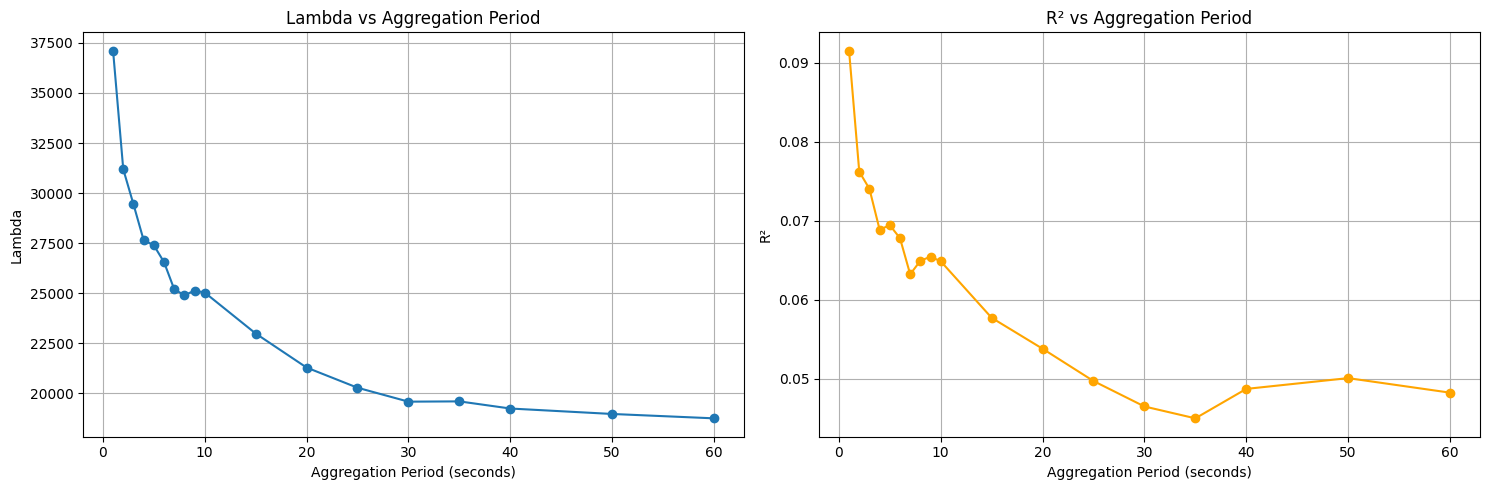

In [21]:
def calculate_lambda(df_market, agg_seconds):
    """Calculate lambda for a given aggregation period"""
    # Resample data
    df_minute = df_market.resample(f'{agg_seconds}s').agg({
        'bid_fill': 'sum',
        'ask_fill': 'sum',
        'Signed Volume': 'sum',
        'best_bid': 'max',
        'best_ask': 'min',
        'Volatility': 'max',
        'ADV': 'max',
    })
    
    # Clean and calculate required fields
    df_minute = df_minute.dropna(subset=['best_bid'])
    df_minute = df_minute.reset_index()
    df_minute['mid_price'] = (df_minute['best_bid'] + df_minute['best_ask']) / 2
    
    # Calculate delta_p and delta_Q
    df_minute['delta_p'] = df_minute['mid_price'].diff().fillna(0)
    df_minute['delta_Q'] = df_minute['Signed Volume'] * df_minute['Volatility'] / df_minute['ADV']
    
    # Linear regression
    X = df_minute[['delta_Q']].values[1:]
    Y = df_minute['delta_p'].values[1:]
    model = LinearRegression()
    model.fit(X, Y)
    
    # Create dictionary of lambda values for ALL periods
    lambda_dict = {f'{agg_seconds}s': model.coef_[0]}  # Store lambda for every period

    return {
        'lambda': model.coef_[0],
        'r2': model.score(X, Y),
        'sample_size': len(X),
        'lambda_dict': lambda_dict
    }

# Define aggregation periods to test (in seconds)
agg_periods = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 50, 60]

# Run grid search
results = []
lambda_values = {}  # Dictionary to store lambda values for key periods

for period in agg_periods:
    result = calculate_lambda(df_market, period)
    results.append({
        'agg_period': period,
        'lambda': result['lambda'],
        'r2': result['r2'],
        'sample_size': result['sample_size']
    })
    # Update lambda_values dictionary if this period has a lambda value
    if result['lambda_dict']:
        lambda_values.update(result['lambda_dict'])

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\nGrid Search Results:")
print(results_df)
print(f"lambda values: {lambda_values}")
# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Lambda vs Aggregation Period
ax1.plot(results_df['agg_period'], results_df['lambda'], marker='o')
ax1.set_xlabel('Aggregation Period (seconds)')
ax1.set_ylabel('Lambda')
ax1.set_title('Lambda vs Aggregation Period')
ax1.grid(True)

# R² vs Aggregation Period
ax2.plot(results_df['agg_period'], results_df['r2'], marker='o', color='orange')
ax2.set_xlabel('Aggregation Period (seconds)')
ax2.set_ylabel('R²')
ax2.set_title('R² vs Aggregation Period')
ax2.grid(True)

plt.tight_layout()
plt.show()

Full coefficients array: [37113.2122553]
Shape of coefficients array: (1,)

All model attributes:
Coefficients: [37113.2122553]
Intercept: 0.0003522903296284939
R² Score: 0.0915511606693512
R^2: 0.0915511606693512


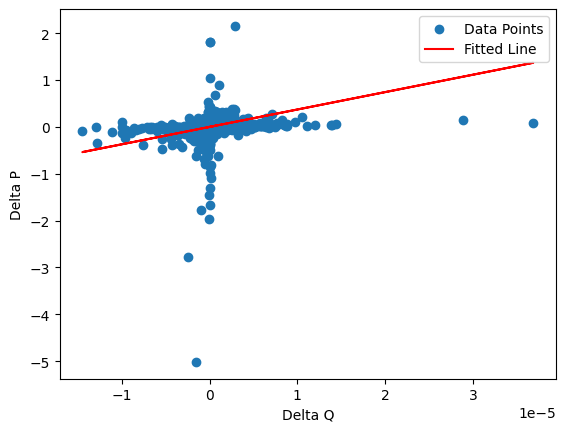

lambda: 37113.21225529705
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.091
Model:                            OLS   Adj. R-squared (uncentered):              0.091
Method:                 Least Squares   F-statistic:                          3.064e+04
Date:                Wed, 18 Dec 2024   Prob (F-statistic):                        0.00
Time:                        11:14:35   Log-Likelihood:                      6.9328e+05
No. Observations:              304750   AIC:                                 -1.387e+06
Df Residuals:                  304749   BIC:                                 -1.387e+06
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------

In [22]:
# Calculate change in price and change in position
df_minute['delta_p'] = df_minute['mid_price'].diff().fillna(0)
df_minute['delta_Q'] = df_minute['Signed Volume'] * df_minute['Volatility'] / df_minute['ADV']

# Linear regression to approximate lambda
X = df_minute[['delta_Q']].values[1:]
Y = df_minute['delta_p'].values[1:]
model = LinearRegression()
model.fit(X, Y)
lambda_value = model.coef_[0]
r2_score = model.score(X, Y)

# Print the full coefficients array
print("Full coefficients array:", model.coef_)

# You can also check its shape
print("Shape of coefficients array:", model.coef_.shape)

# For more details about the model, you can print:
print("\nAll model attributes:")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("R² Score:", model.score(X, Y))

# t-test and F-test for linearity
print(f"R^2: {r2_score}")
plt.scatter(X, Y, label='Data Points')
plt.plot(X, model.predict(X), color='red', label='Fitted Line')
plt.xlabel('Delta Q')
plt.ylabel('Delta P')
plt.legend()
plt.show()
print(f'lambda: {lambda_value}')

# Fit the linear regression model using statsmodels
model = sm.OLS(Y, X).fit()

# Print the summary of the regression, which includes t-tests and F-test
print(model.summary())

lamdba log
1s: 1316.277
2s: 1191.047
10s: 853.806

### Estimate Beta

In [23]:
# set beta to hour frequency
h_minutes = 60 # hour-wise frequency

#input is h_minutes: h_minutes=60mins means the traded volume will influence the following 60 mins (exponential decay)
h_hours = h_minutes / 60

# Calculate beta using half-life transformation
beta = math.log(2) / h_hours
print(f'beta: {beta}')

beta: 0.6931471805599453


### Calculate Impact I
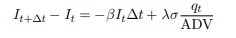

In [24]:
# Calculate number of rows and columns needed for subplots
n_plots = len(lambda_values)
n_cols = 6  # We'll use 6 columns
n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division to get required rows

# Create figure with subplots
plt.figure(figsize=(20, 3*n_rows))  # Adjust figure size based on number of rows

# Calculate Impact for each lambda value (this part remains the same)
impacts = {}
for period, lambda_val in lambda_values.items():
    price_impact = [0 for i in range(df_minute.shape[0])]
    delta_t = 1
    
    for time_i in range(df_minute.shape[0]-1):
        if df_minute.iloc[time_i,0].hour == 13:
            continue
        I_t = price_impact[time_i]
        delta_I = lambda_val * df_minute.iloc[time_i,6] * df_minute.iloc[time_i,3] / df_minute.iloc[time_i,7] - beta * I_t * delta_t
        price_impact[time_i+1] = I_t + delta_I
    
    impacts[period] = price_impact
    df_minute[f'price_impact_{period}'] = price_impact

# Plot histograms in grid
for i, (period, impact) in enumerate(impacts.items(), 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(impact, bins=50, label=f'λ={lambda_values[period]:.2f}')
    plt.title(f'Impact ({period})')
    plt.xlabel('Price Impact')
    plt.ylabel('Frequency')
    plt.legend(fontsize='small')

plt.tight_layout()
plt.show()

Impact Distribution Statistics:
        mean  median     std     min     max      lambda       cv
100s  0.0001     0.0  0.0037 -0.1026  0.1545   2448.4063  48.9183
10s   0.0003     0.0  0.0130 -0.3595  0.5414   8580.2182  48.9183
110s  0.0000     0.0  0.0023 -0.0634  0.0955   1512.9115  48.9183
120s  0.0001     0.0  0.0051 -0.1403  0.2113   3349.2425  48.9183
130s  0.0001     0.0  0.0027 -0.0749  0.1128   1788.2282  48.9183
140s  0.0001     0.0  0.0030 -0.0818  0.1232   1953.1057  48.9183
150s  0.0000     0.0  0.0020 -0.0540  0.0813   1288.2230  48.9183
15s   0.0002     0.0  0.0108 -0.2978  0.4485   7108.3733  48.9183
160s  0.0001     0.0  0.0028 -0.0761  0.1146   1816.3962  48.9183
170s  0.0000     0.0  0.0015 -0.0408  0.0615    974.8992  48.9183
180s  0.0000     0.0  0.0023 -0.0637  0.0959   1519.7088  48.9183
190s  0.0001     0.0  0.0029 -0.0808  0.1216   1927.8238  48.9183
1s    0.0005     0.0  0.0231 -0.6383  0.9613  15235.5845  48.9183
200s  0.0000     0.0  0.0011 -0.0292  0.0440

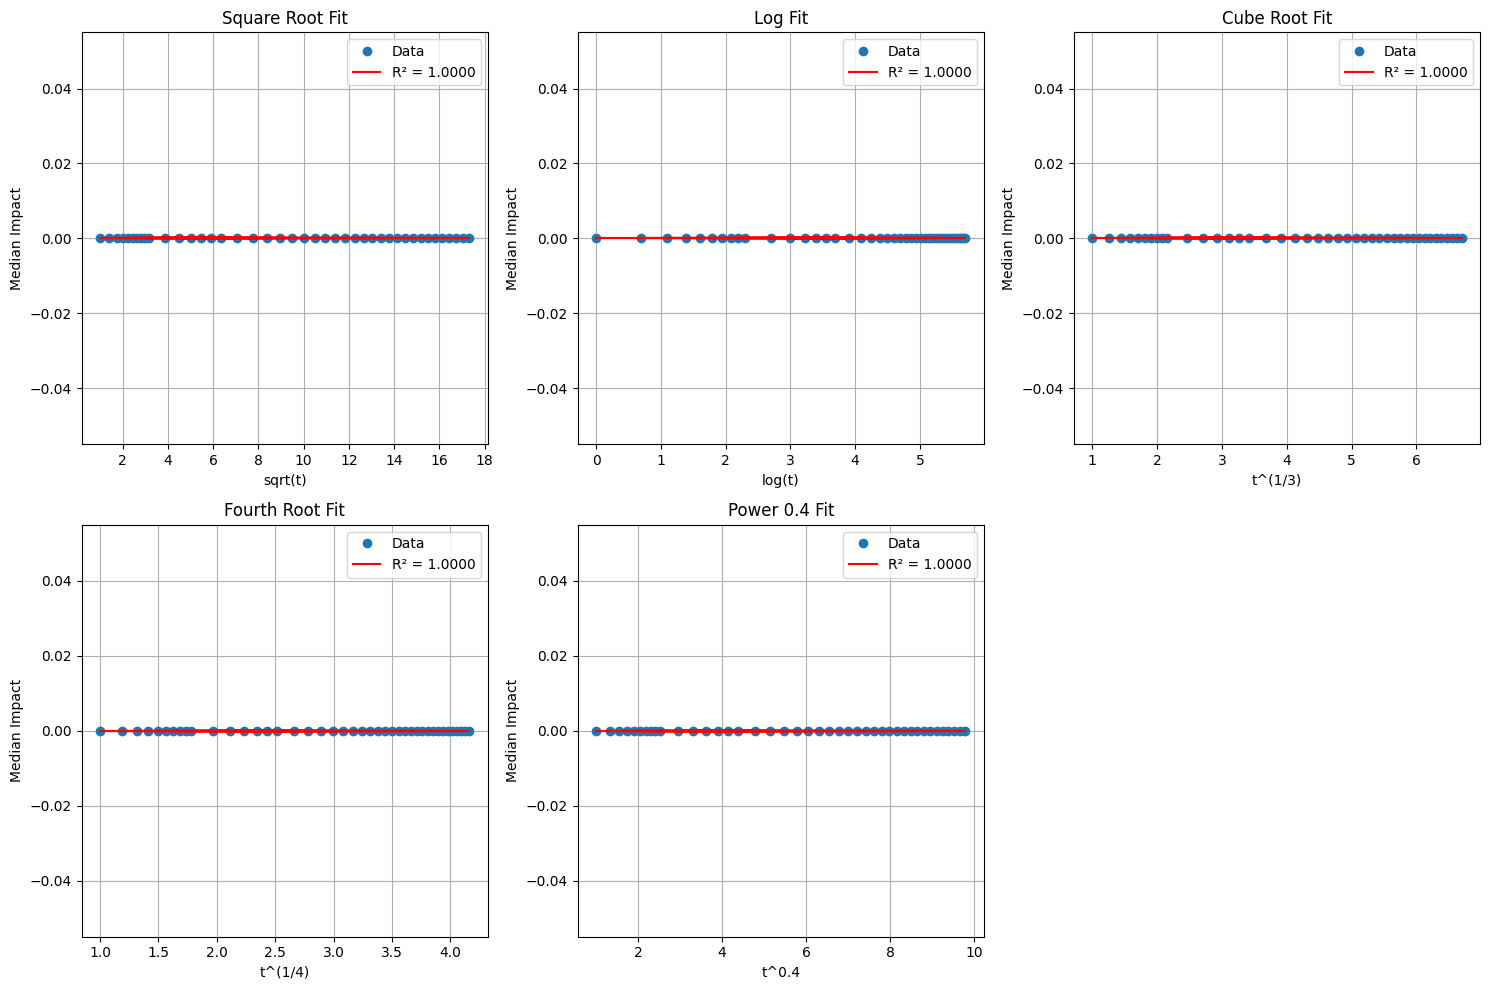

In [53]:
# Calculate statistics for each impact distribution
impact_stats = {}
for period, impact in impacts.items():
    stats = {
        'mean': np.mean(impact),
        'median': np.median(impact),
        'std': np.std(impact),
        'min': np.min(impact),
        'max': np.max(impact),
        'lambda': lambda_values[period]
    }
    impact_stats[period] = stats

# Convert to DataFrame for better visualization
stats_df = pd.DataFrame.from_dict(impact_stats, orient='index')
stats_df = stats_df.sort_index()

# Add a column for coefficient of variation (CV = std/mean)
stats_df['cv'] = stats_df['std'] / stats_df['mean'].abs()

# Display the statistics
print("Impact Distribution Statistics:")
print(stats_df.round(4))

# # Extract periods and convert to numeric values for x-axis
# periods = [int(p.replace('s', '')) for p in stats_df.index]  # Convert '10s' to 10

# plt.figure(figsize=(12, 6))
# plt.plot(periods, stats_df['median'], marker='o', linestyle='', linewidth=2)  # Removed linestyle='-'
# plt.xlabel('Period (seconds)')
# plt.ylabel('Median Impact')
# plt.title('Median Impact vs Period')
# plt.grid(True)

# plt.tight_layout()
# plt.show()
# Extract periods and convert to numeric values for x-axis
# Extract periods and convert to numeric values for x-axis
# Extract periods and prepare data
periods = np.array([int(p.replace('s', '')) for p in stats_df.index])
medians = stats_df['median'].values

# Create figure for multiple fits
plt.figure(figsize=(15, 10))

# Test different relationships
fits = {
    'Square Root': (lambda x: np.sqrt(x), 'sqrt(t)'),
    'Log': (lambda x: np.log(x), 'log(t)'),
    'Cube Root': (lambda x: np.power(x, 1/3), 't^(1/3)'),
    'Fourth Root': (lambda x: np.power(x, 1/4), 't^(1/4)'),
    'Power 0.4': (lambda x: np.power(x, 0.4), 't^0.4')
}

# Plot each fit
for i, (name, (func, label)) in enumerate(fits.items()):
    X = func(periods).reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, medians)
    y_pred = model.predict(X)
    r2 = model.score(X, medians)
    
    plt.subplot(2, 3, i+1)
    plt.plot(X, medians, 'o', label='Data')
    plt.plot(X, y_pred, 'r-', label=f'R² = {r2:.4f}')
    plt.xlabel(label)
    plt.ylabel('Median Impact')
    plt.title(f'{name} Fit')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# Optional: Save to CSV
# stats_df.to_csv('impact_statistics.csv')

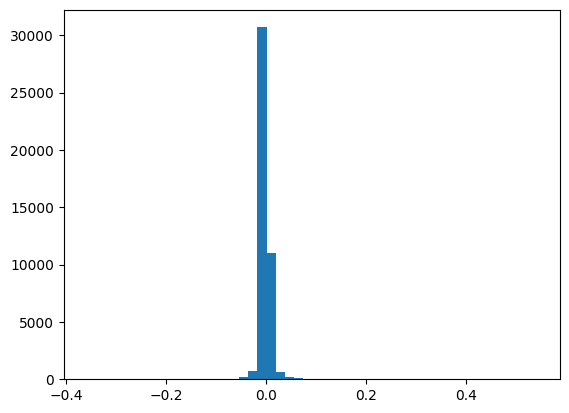

In [54]:
# Reset just to be sure
df_minute = df_minute.reset_index(drop=True)

#
price_impact = [0 for i in range(df_minute.shape[0])] # treat start of each trade day as I_0 = 0
delta_t = 1 # 1 unit time step. Doesn't matter if it's sec, min, hr, etc. As long as the data HAS UNIFORM TIME STEPS
lambda_t = lambda_value
for time_i in range(df_minute.shape[0]-1):
    if df_minute.iloc[time_i,0].hour==13: # start of each day, but it relies on the frequency that is hour-wise
        continue
    I_t = price_impact[time_i]
    delta_I = lambda_t * df_minute.iloc[time_i,6] * df_minute.iloc[time_i,3] / df_minute.iloc[time_i,7] - beta * I_t * delta_t
    price_impact[time_i+1] = I_t + delta_I
df_minute['price_impact'] = price_impact

plt.hist(df_minute['price_impact'], bins=50)
plt.show()

### Calculate Alpha

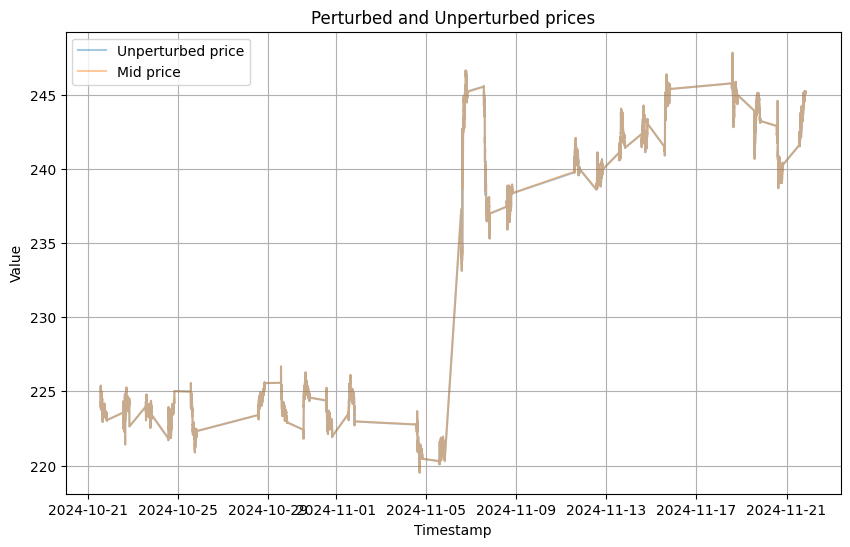

C:\Users\Colter\AppData\Local\Temp\ipykernel_19544\2056558904.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return data.groupby('date').apply(


In [55]:
df_minute['unperturbed_price'] = df_minute['mid_price'] - df_minute['price_impact']
plt.figure(figsize=(10, 6))
plt.plot(df_minute['ts_event'], df_minute['unperturbed_price'], alpha=0.4,label='Unperturbed price')
plt.plot(df_minute['ts_event'], df_minute['mid_price'], alpha=0.4,label='Mid price')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('Perturbed and Unperturbed prices')
plt.legend()
plt.grid(True)
plt.show()

def determined_strategy(data):
    """
    Function to estimate alpha.
    Args:
        data (pd.DataFrame): Financial data with 'ts_event' and 'price' columns.

    Returns:
        dict: Keys as dates and values as calculated price differences.
    """
    # Extract date and time components
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time

    # Get the closing price for each date
    end_time = pd.to_datetime('20:00:00').time()
    
    filtered_data = data
    # closing_prices = filtered_data[filtered_data['time'] == end_time].set_index('date')['unperturbed_price']

    def time_to_minutes(t):
        return t.hour * 60 + t.minute

    # Get the last price within some tolerance of market close
    def get_closing_prices(data):
        end_minutes = time_to_minutes(end_time)
        return data.groupby('date').apply(
            lambda x: x.iloc[(abs(x['time'].apply(time_to_minutes) - end_minutes)).argsort()[:1]]['unperturbed_price'].iloc[0]
        )
    closing_prices = get_closing_prices(filtered_data)
    

    # Calculate the new prices for each date
    def calculate_difference(row):
        return row['unperturbed_price'] - closing_prices.get(row['date'], np.nan)
    
    # Alpha = S_T - S_t
    filtered_data['determined_alpha'] = filtered_data.apply(calculate_difference, axis=1)
    # for i in range(len(filtered_data)-1):
    #     if pd.isna(filtered_data['determined_alpha'].iloc[i]):
    #         print(f"end time: {filtered_data['ts_event'].iloc[i]}")
    #         print(f"closing prices: {closing_prices.iloc[i]}")
    #         print(f"alpha: {filtered_data['determined_alpha'].iloc[i]}")
        # Debug NaN values without accessing closing_prices directly
    nan_rows = filtered_data[filtered_data['determined_alpha'].isna()]
    if not nan_rows.empty:
        for _, row in nan_rows.iterrows():
            print(f"end time: {row['ts_event']}")
            print(f"date: {row['date']}")
            print(f"alpha: {row['determined_alpha']}")
            print(f"unperturbed_price: {row['unperturbed_price']}")
            print(f"closing_prices.get: {closing_prices.get(row['date'], np.nan)}")
            if row['date'] in closing_prices.index:
                print(f"closing price for date: {closing_prices[row['date']]}")
            else:
                print(f"No closing price found for date: {row['date']}")
            print("---")
            
    filtered_data.drop('date', axis=1, inplace=True)
    filtered_data.drop('time', axis=1, inplace=True)

    return filtered_data

res = determined_strategy(df_minute)

## Calculate nu

In [56]:
def nu(data, beta, lambda_t, Q_0, T=390):
    """
    Function to estimate nu.
    Args:
        data (pd.DataFrame): Financial data with 'ts_event' and 'determined_alpha' columns.
        beta (float): A parameter.
        lambda_t (float): Another parameter.
        Q_0: Input of the strategy (assume side / size / timeframe(default to be 1 day) )
        T (float): Total time, default is 390 minutes each day.

    Returns:
        pd.DataFrame: Original data with a new 'determined_nu' column.
    """
    data = data.copy()  # Avoid modifying the original DataFrame
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time
    start_time = pd.to_datetime('13:30:00').time()
    
    def calculate_nu(group):
        # Get 'determined_alpha' at start_time
        q_0 = Q_0 * group['Volatility'] / group['ADV']
        start_alpha_series = group.loc[group['time'] == start_time, 'determined_alpha']
        if not start_alpha_series.empty:
            start_alpha = start_alpha_series.iloc[0]
        else:
            # Handle case where start_time is not present
            start_alpha = 0  # Or use an appropriate default value
        start_alpha = np.full(len(group),start_alpha)
        summed_alpha = group['determined_alpha'].sum()
        summed_alpha = np.full(len(group),summed_alpha)
        res = (start_alpha + beta * summed_alpha + 2 * lambda_t * q_0) * -1 / (2 + beta * T)
        return pd.Series(res, index=group.index)
    
    # Compute 'determined_nu' per date
    data['determined_nu'] = data.groupby('date').apply(calculate_nu,include_groups=False).reset_index(level=0, drop=True)
    
    
    # Clean up
    data.drop(['date', 'time'], axis=1, inplace=True)
    return data

Q_0 = 3900000 # we assume that the client hope to sell 390 shares of AAPL today
res = nu(res, beta, lambda_t, Q_0)

## Calculate Alpha Prime, I Prime, I*, I* Prime

In [57]:
def alpha_prime(data):
    """
    Function to estimate the difference of 'determined_alpha' per day.
    Args:
        data (pd.DataFrame): Financial data with 'ts_event' and 'determined_alpha' columns.

    Returns:
        pd.DataFrame: Original data with a new 'determined_alpha_prime' column.
    """
    data = data.copy()  # Avoid modifying the original DataFrame
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time
    end_time = pd.to_datetime('20:00:00').time()

    def calculate_alpha_prime(group):
        # Ensure the group is sorted by 'ts_event' if necessary
        group = group.sort_values('ts_event')
        res = group['determined_alpha'].diff()
        return res

    def calculate_I_prime(group):
        res = group['price_impact'].diff().fillna(0)
        return res
    
    def calculate_I_star(group, nu=0):
        '''stochastic I_star where nu=0, but here we assume we have perfect alpha estimation
        '''
        res = ((group['determined_alpha'] - (group['determined_alpha_prime'] / beta))/2).fillna(0)
        res[group['time']==end_time] = nu
        return res

    def calculate_I_star_prime(group):
        res = group['I_star_t'].diff().fillna(0)
        return res
    
    def calculate_delta_Q_star(group):
        res = ((group['I_star_t'].diff() + beta * group['I_star_t'])/lambda_t).fillna(0)
        return res
    
    # Compute 'determined_alpha_prime' per date and align with original index
    data['determined_alpha_prime'] = data.groupby('date').apply(calculate_alpha_prime,include_groups=False).reset_index(level=0, drop=True)
    data['I_star_t'] = data.groupby('date').apply(calculate_I_star,include_groups=False).reset_index(level=0, drop=True)
    data['I_prime'] = data.groupby('date').apply(calculate_I_prime,include_groups=False).reset_index(level=0, drop=True)
    data['I_star_prime'] = data.groupby('date').apply(calculate_I_star_prime,include_groups=False).reset_index(level=0, drop=True)
    data['delta_Q_star'] = data.groupby('date').apply(calculate_delta_Q_star,include_groups=False).reset_index(level=0, drop=True)
    
    # Clean up
    data.drop(['date', 'time'], axis=1, inplace=True)
    return data

res = alpha_prime(res)

## Calculate Delta Q*, market objective function, optimized objective function

In [58]:
res['myopic_market_obj'] = (beta * res['determined_alpha'] * res['price_impact'] - res['determined_alpha_prime'] * res['price_impact'] - beta*res['price_impact']**2).fillna(0)
res['myopic_opt_obj'] = (beta * res['determined_alpha'] * res['I_star_t'] - res['determined_alpha_prime'] * res['I_star_t'] - beta*res['I_star_t']**2).fillna(0)

## Calculate PnL

In [59]:
def PnL(data, beta, lambda_t, Q_0):
    """
    Function to add column PnL.
    Args:
        data (pd.DataFrame): Financial data with 'ts_event' and 'determined_alpha' columns.
        Q_0 : input of the strategy, from client
    Returns:
        pd.DataFrame: Original data with new calculated 'determined_nu' columns.
    """
    data = data.copy()  # Avoid modifying the original DataFrame
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time
    start_time = pd.to_datetime('13:30:00').time()
    end_time = pd.to_datetime('20:00:00').time()
    
    def calculate_optimal_PnL(group):
        res = ((group['determined_alpha'] - group['I_star_t']) * group['delta_Q_star']).cumsum()
        return res
    
    def calculate_PnL(group):
        res = ((group['determined_alpha'] - group['price_impact']) * group['delta_Q']).cumsum()
        return res

    def calculate_integral(group):
        integral_value = group['myopic_market_obj'].cumsum() / lambda_t
        return pd.Series(integral_value, index=group.index)

    def calculate_optimal_integral(group):
        optimal_integral_value = group['myopic_opt_obj'].cumsum() / lambda_t
        return pd.Series(optimal_integral_value, index=group.index)
    
    def calculate_optimal_position(group):
        summed_alpha = group['determined_alpha'].sum()
        if group[group['time'] == start_time].empty:
            #Q0 = 0  # Default value
            q_0 = 0
        else:
            #Q0 = -1 * (group[group['time'] == start_time]['determined_alpha'].iloc[0] + beta * summed_alpha) / (2 * lambda_t) # nu=0
            q_0 = Q_0 * group['Volatility'] / group['ADV']
        q0_vector = np.full(len(group), q_0)
        a = q0_vector + group['delta_Q_star'].cumsum()
        return a
    
    def calculate_vwap(group):
        VWAP = (group['bid_fill'] + group['ask_fill'])/((group['bid_fill']+group['ask_fill']).sum())
        summed_alpha = group['determined_alpha'].sum()
        if group[group['time'] == start_time].empty:
            #Q0 = 0  # Default value
            q_0 = 0
        else:
            q_0 = Q_0 * group['Volatility'] / group['ADV']
        q0_vector = np.full(len(group), q_0)
        position_vwap = q0_vector - q0_vector * VWAP.cumsum()
        return position_vwap
    
    def calculate_vwap_delta_Q(group):
        res = group['vwap_position'].diff().fillna(0)
        return res
    
    def calculate_vwap_price_impact(group):
        I = [0]  
        for t in range(1, len(group)): 
            I_next = I[-1] - I[-1] * beta + lambda_t * group.iloc[t-1]['vwap_delta_Q']
            I.append(I_next) 
        return pd.Series(I, index=group.index)
    
    def calculate_vwap_PnL(group):
        res = ((group['determined_alpha'] - group['vwap_I']) * group['vwap_delta_Q']).cumsum()
        return res
    
    def calculate_twap(group):
        TWAP = np.full(len(group), 1)/len(group)
        summed_alpha = group['determined_alpha'].sum()
        if group[group['time'] == start_time].empty:
            #Q0 = 0  # Default value
            q_0 = 0
        else:
            q_0 = Q_0 * group['Volatility'] / group['ADV']
        q0_vector = np.full(len(group), q_0)
        position_twap = q0_vector - q0_vector * TWAP.cumsum()
        return pd.Series(position_twap, index=group.index)
    
    def calculate_twap_delta_Q(group):
        res = group['twap_position'].diff().fillna(0)
        return res
    
    def calculate_twap_price_impact(group):
        I = [0]
        for t in range(1, len(group)):  
            I_next = I[-1] - I[-1] * beta + lambda_t * group.iloc[t-1]['twap_delta_Q']
            I.append(I_next)
        return pd.Series(I, index=group.index)

    def calculate_twap_PnL(group):
        res = ((group['determined_alpha'] - group['twap_I']) * group['twap_delta_Q']).cumsum()
        return res   
    
    data['optimal_PnL'] = data.groupby('date').apply(calculate_optimal_PnL).reset_index(level=0, drop=True)
    data['PnL'] = data.groupby('date').apply(calculate_PnL).reset_index(level=0, drop=True)
    data['integral'] = data.groupby('date').apply(calculate_integral).reset_index(level=0, drop=True)
    data['optimal_integral'] = data.groupby('date').apply(calculate_optimal_integral).reset_index(level=0, drop=True)
    data['optimal_position'] = data.groupby('date').apply(calculate_optimal_position,include_groups=False).reset_index(level=0, drop=True)
    data['vwap_position'] = data.groupby('date').apply(calculate_vwap, include_groups=False).reset_index(level=0, drop=True)
    data['vwap_delta_Q'] = data.groupby('date').apply(calculate_vwap_delta_Q, include_groups=False).reset_index(level=0, drop=True)
    data['vwap_I'] = data.groupby(data['date']).apply(calculate_vwap_price_impact,include_groups=False).reset_index(level=0, drop=True)
    data['vwap_PnL'] = data.groupby('date').apply(calculate_vwap_PnL, include_groups=False).reset_index(level=0, drop=True)
    data['twap_position'] = data.groupby('date').apply(calculate_twap,include_groups=False).reset_index(level=0, drop=True)
    data['twap_delta_Q'] = data.groupby('date').apply(calculate_twap_delta_Q, include_groups=False).reset_index(level=0, drop=True)
    data['twap_I'] = data.groupby(data['date']).apply(calculate_twap_price_impact,include_groups=False).reset_index(level=0, drop=True)
    data['twap_PnL'] = data.groupby('date').apply(calculate_twap_PnL, include_groups=False).reset_index(level=0, drop=True)
    # Clean up
    data.drop(['date', 'time'], axis=1, inplace=True)
    return data

# Example usage
res = PnL(res, beta, lambda_t, Q_0)

C:\Users\Colter\AppData\Local\Temp\ipykernel_19544\491612741.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data['optimal_PnL'] = data.groupby('date').apply(calculate_optimal_PnL).reset_index(level=0, drop=True)
C:\Users\Colter\AppData\Local\Temp\ipykernel_19544\491612741.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data['PnL'] = data.groupby('date').apply(calculate_PnL).reset_index(level=0, d

## Resulting data frame with all the newly calculated columns

## Visualize 

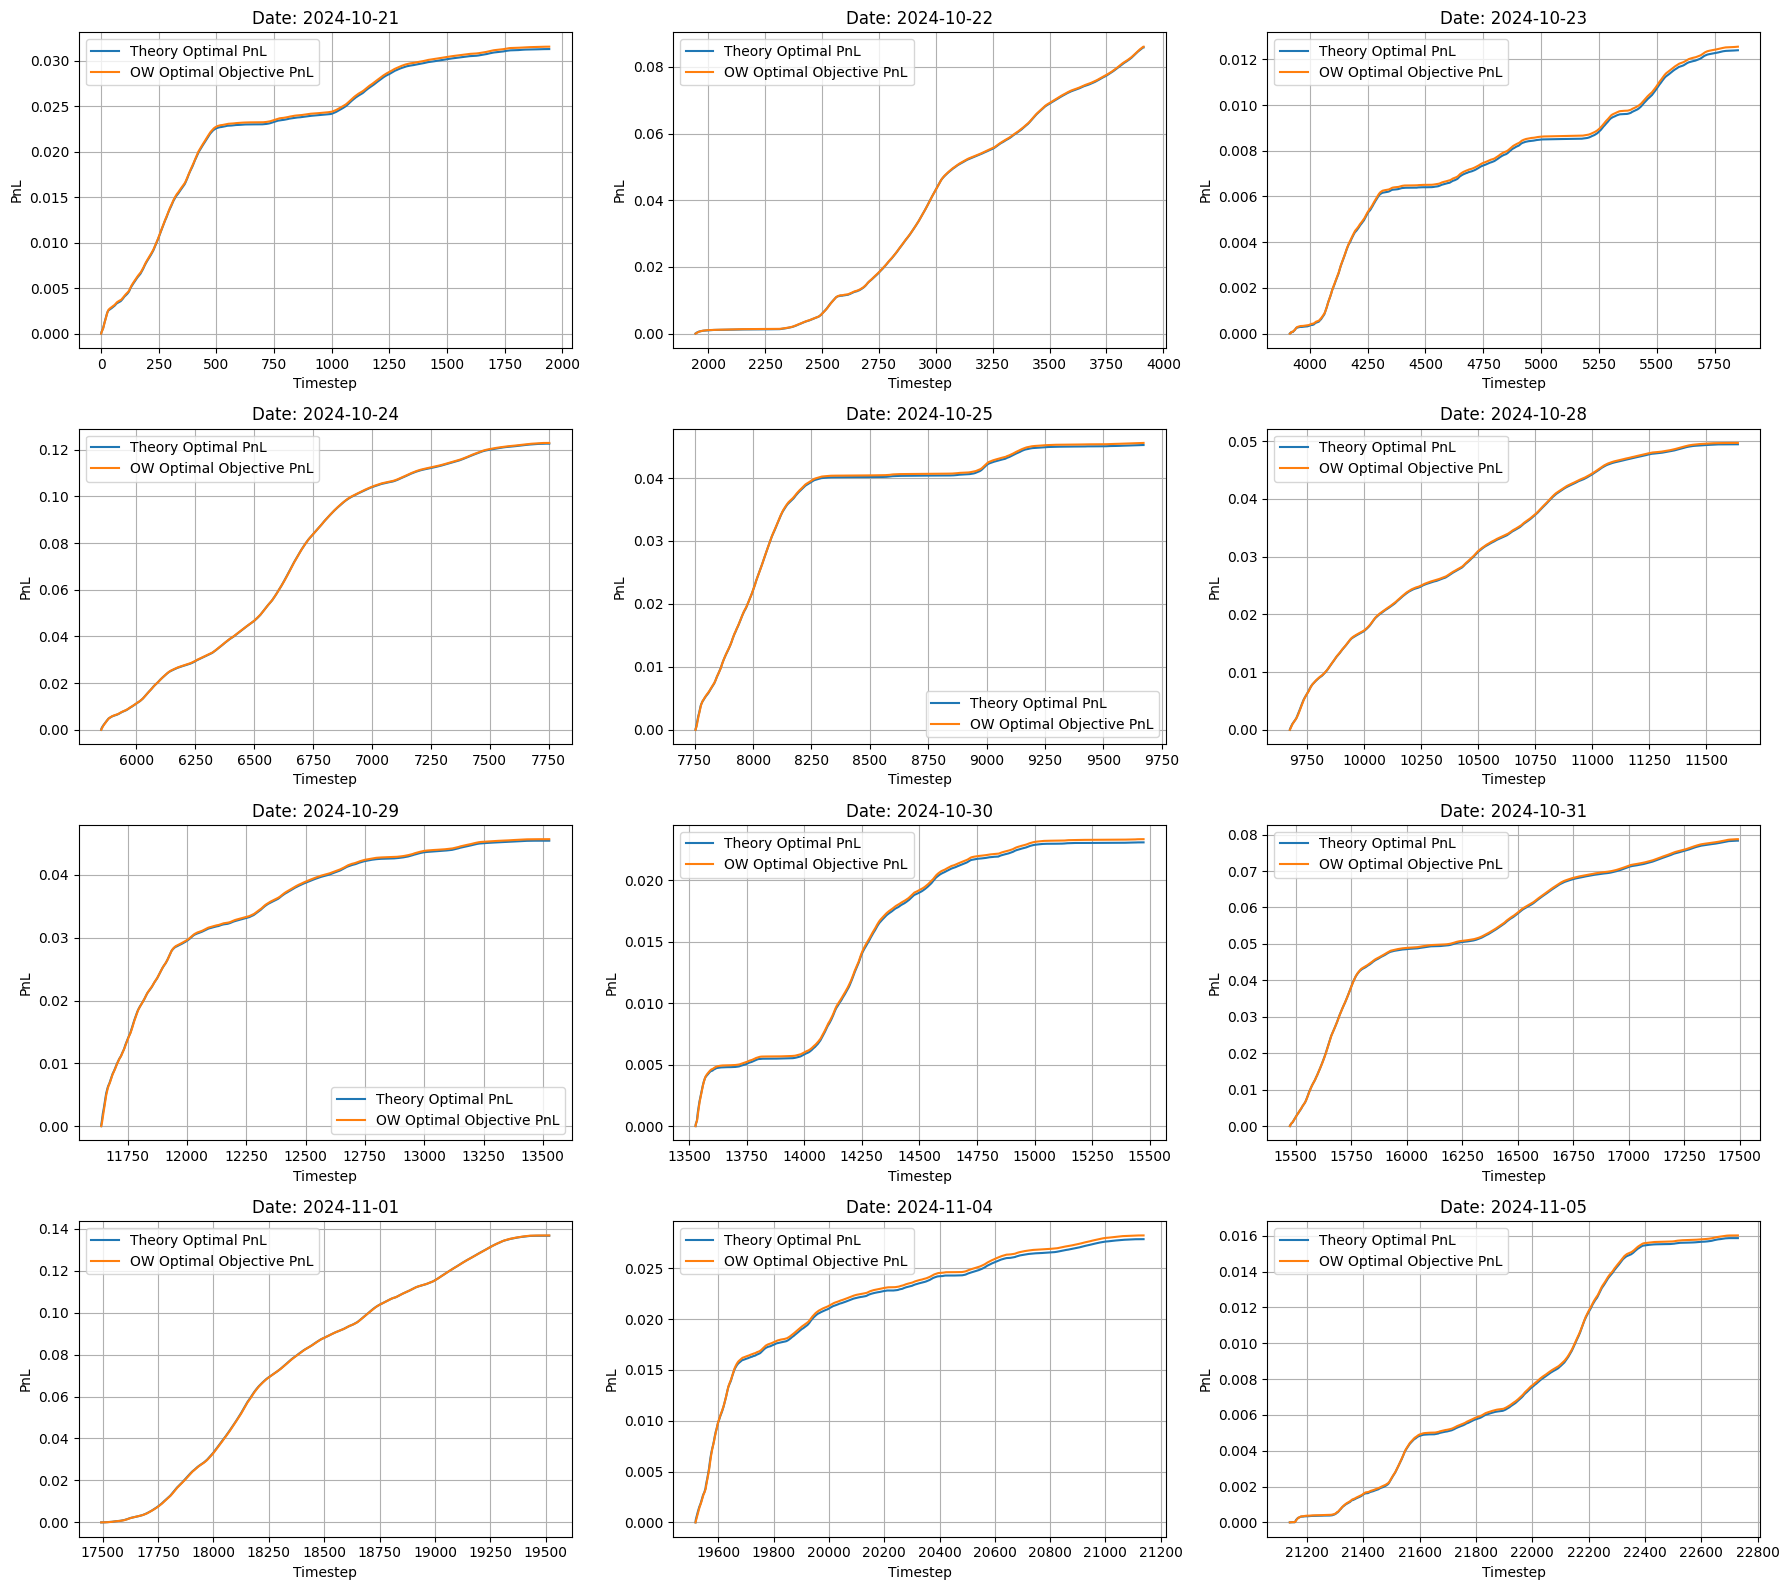

In [61]:
# Ensure 'ts_event' is in datetime format and extract the 'date' column
res['ts_event'] = pd.to_datetime(res['ts_event'])
res['date'] = res['ts_event'].dt.date

# Get the list of unique dates and select the first 12 days
unique_dates = res['date'].unique()
first_12_days = unique_dates[:12]

# Filter the DataFrame to include only the first 12 days
filtered_res = res[res['date'].isin(first_12_days)].copy()

# Prepare for plotting
num_days = len(first_12_days)
nrows = 4
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 16))
axes = axes.flatten()  # Flatten the axes array for easy indexing

# Loop over each day and plot histograms
for i, date in enumerate(first_12_days):
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    # Plotting histograms for 'integral' and 'optimal_integral'
    ax = axes[i]
    #ax.plot(day_data['PnL'], label='Market PnL')
    ax.plot(day_data['optimal_PnL'], label='Theory Optimal PnL')
    #ax.plot(day_data['integral'] ,label='OW Objective PnL')
    ax.plot(day_data['optimal_integral'], label='OW Optimal Objective PnL')
    
    # Formatting
    ax.set_xlabel('Timestep')
    ax.set_ylabel('PnL')
    ax.set_title(f'Date: {date}')
    ax.legend()
    ax.grid(True)

# Hide any unused subplots
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\Colter\AppData\Local\Temp\ipykernel_19544\2741150799.py:58: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


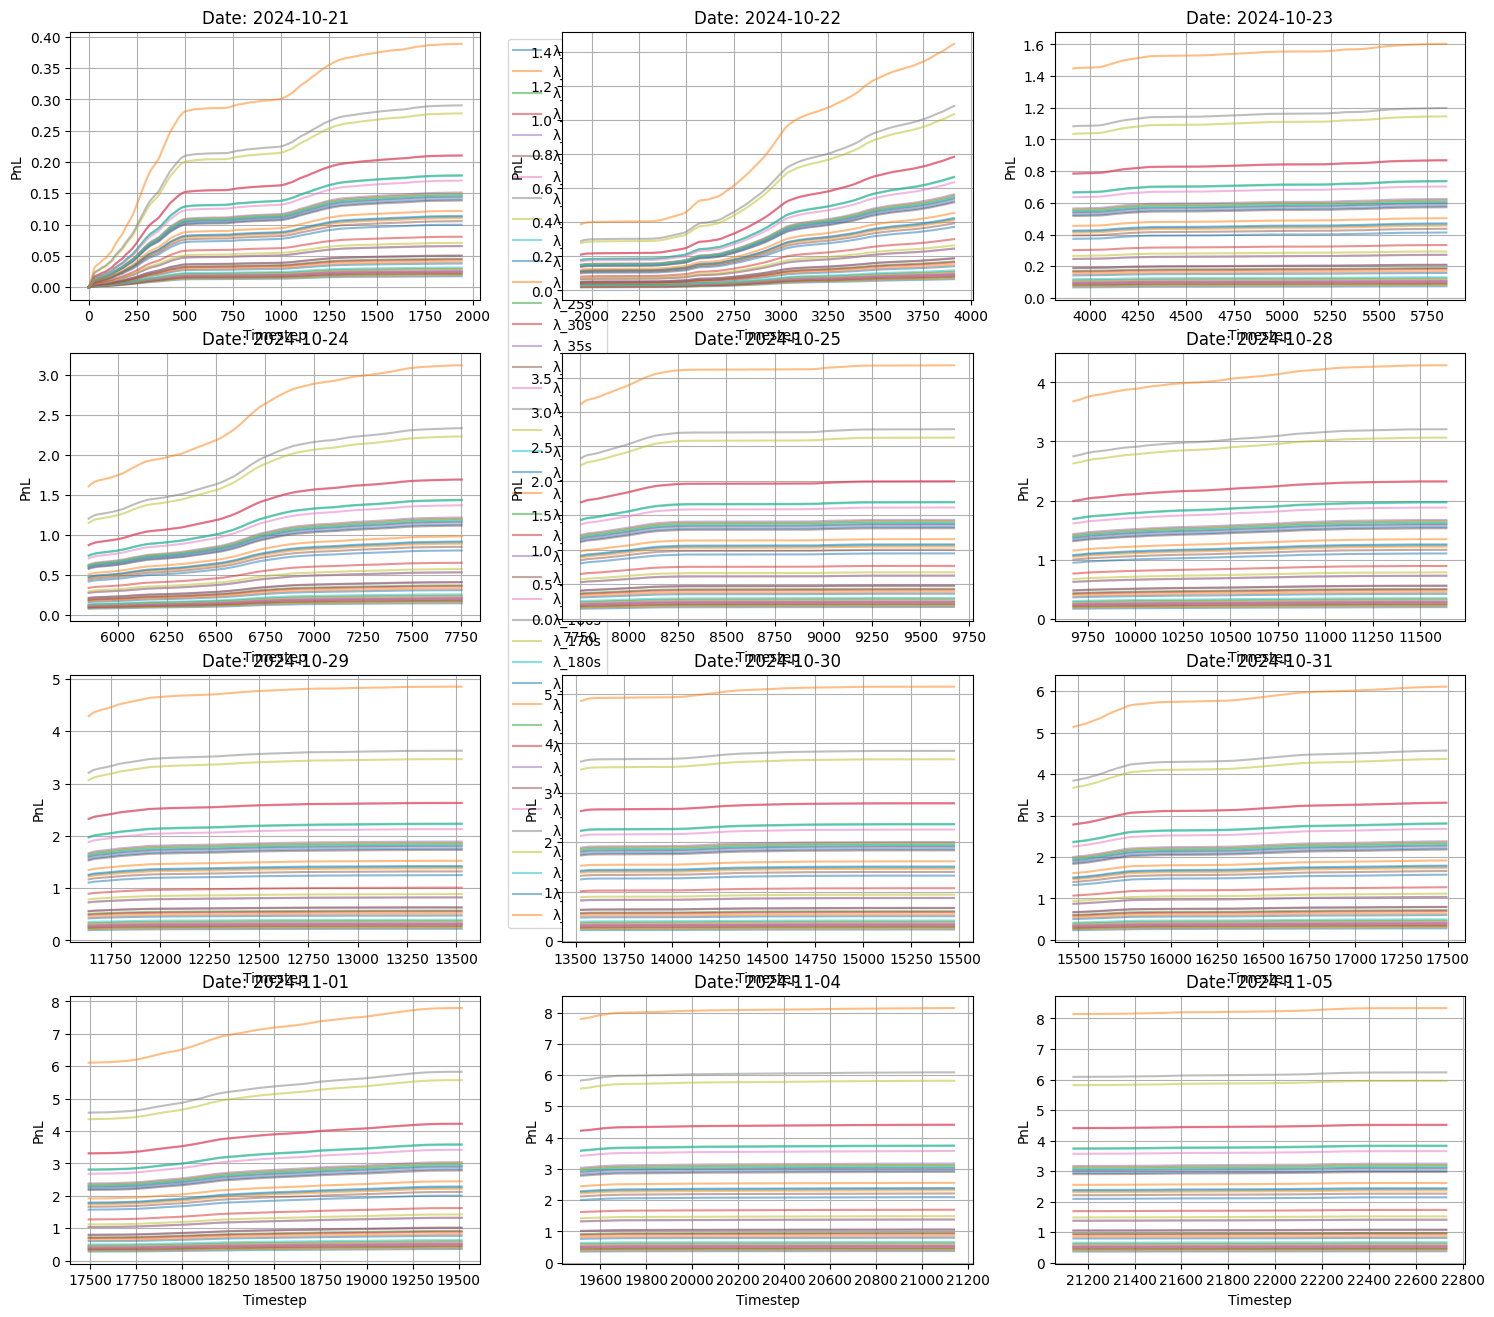


PnL Statistics for different lambda values:
      final_pnl  mean_pnl  std_pnl  sharpe      lambda
1s       1.1200    0.5694   0.4066  1.4004  15235.5845
2s       1.2407    0.6307   0.4504  1.4004  13753.8644
3s       1.3473    0.6849   0.4891  1.4004  12665.6764
4s       1.4332    0.7286   0.5203  1.4004  11906.4064
5s       1.5786    0.8025   0.5730  1.4004  10809.6417
6s       1.6228    0.8249   0.5891  1.4004  10515.3206
7s       1.6380    0.8327   0.5946  1.4004  10417.5423
8s       1.8321    0.9313   0.6651  1.4004   9313.8998
9s       1.8609    0.9459   0.6755  1.4004   9170.1536
10s      1.9888    1.0110   0.7219  1.4004   8580.2182
15s      2.4006    1.2203   0.8714  1.4004   7108.3733
20s      2.5802    1.3116   0.9366  1.4004   6613.4532
25s      2.8824    1.4652   1.0463  1.4004   5920.2144
30s      2.7960    1.4213   1.0150  1.4004   6103.0471
35s      3.1680    1.6104   1.1500  1.4004   5386.5068
40s      3.2015    1.6274   1.1622  1.4004   5330.1614
50s      4.1405    2

In [62]:
# Ensure 'ts_event' is in datetime format and extract the 'date' column
res['ts_event'] = pd.to_datetime(res['ts_event'])
res['date'] = res['ts_event'].dt.date

# Get the list of unique dates
unique_dates = res['date'].unique()

# Create a figure with subplots
num_days = len(unique_dates[:12])  # First 12 days as before
nrows = 4
ncols = 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 16))
axes = axes.flatten()

# Dictionary to store PnL results for each lambda
pnl_results = {}

# Calculate PnL for each lambda value
for period, lambda_val in lambda_values.items():
    # Recalculate optimal quantities and PnL using this lambda
    temp_df = res.copy()
    
    # Calculate I* and related values with the current lambda
    temp_df['I_star_t'] = ((temp_df['determined_alpha'] - 
                           (temp_df['determined_alpha_prime'] / beta))/2).fillna(0)
    temp_df['I_star_prime'] = temp_df['I_star_t'].diff().fillna(0)
    temp_df['delta_Q_star'] = ((temp_df['I_star_t'].diff() + 
                               beta * temp_df['I_star_t'])/lambda_val).fillna(0)
    
    # Calculate optimal integral
    temp_df['optimal_integral'] = (temp_df['myopic_opt_obj'].cumsum() / lambda_val).fillna(0)
    
    pnl_results[period] = temp_df['optimal_integral']

# Plot PnL for first 12 days
for i, date in enumerate(unique_dates[:12]):
    ax = axes[i]
    day_data = res[res['date'] == date]
    
    # Plot PnL for each lambda value
    for period, pnl in pnl_results.items():
        day_pnl = pnl[res['date'] == date]
        ax.plot(day_pnl, label=f'λ_{period}', alpha=0.5)
    
    ax.set_title(f'Date: {date}')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('PnL')
    ax.grid(True)
    
    # Only show legend for first subplot to avoid clutter
    if i == 0:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Hide any unused subplots
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Calculate summary statistics for each lambda's PnL
pnl_stats = {}
for period, pnl in pnl_results.items():
    stats = {
        'final_pnl': pnl.iloc[-1],
        'mean_pnl': pnl.mean(),
        'std_pnl': pnl.std(),
        'sharpe': pnl.mean() / pnl.std() if pnl.std() != 0 else 0,
        'lambda': lambda_values[period]
    }
    pnl_stats[period] = stats

# Convert to DataFrame and display
pnl_stats_df = pd.DataFrame.from_dict(pnl_stats, orient='index')
print("\nPnL Statistics for different lambda values:")
print(pnl_stats_df.round(4))

In [ ]:
import matplotlib.dates as mdates

res['ts_event'] = pd.to_datetime(res['ts_event'])
res['date'] = res['ts_event'].dt.date

# Get the list of unique dates and select the first 6 days
unique_dates = res['date'].unique()
first_6_days = unique_dates[:12]

# Filter the DataFrame to include only the first 6 days
filtered_res = res[res['date'].isin(first_6_days)].copy()

# Sort the data by 'ts_event' within each day
filtered_res.sort_values(['date', 'ts_event'], inplace=True)

# Prepare for plotting
num_days = len(first_6_days)
nrows = 4
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 16))
axes = axes.flatten()  # Flatten the axes array for easy indexing

# Loop over each day and plot the time series
for i, date in enumerate(first_6_days):
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    # Plotting

    ax = axes[i]
    ax.plot(day_data['ts_event'], day_data['optimal_position'], label='Myopic Trade Process')
    ax.plot(day_data['ts_event'], day_data['vwap_position'], label='VWAP Trade Process')
    ax.plot(day_data['ts_event'], day_data['twap_position'], label='TWAP Trade Process')
    
    
    # Formatting the x-axis to show time only
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel('Time')
    ax.set_ylabel('Position')
    ax.set_title(f'Date: {date}')
    ax.legend()
    ax.grid(True)
    
    # # Rotate x-axis labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Hide any unused subplots if there are any
for j in range(i+1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.dates as mdates

res['ts_event'] = pd.to_datetime(res['ts_event'])
res['date'] = res['ts_event'].dt.date

# Get the list of unique dates and select the first 6 days
unique_dates = res['date'].unique()
first_6_days = unique_dates[:12]

# Filter the DataFrame to include only the first 6 days
filtered_res = res[res['date'].isin(first_6_days)].copy()

# Sort the data by 'ts_event' within each day
filtered_res.sort_values(['date', 'ts_event'], inplace=True)

# Prepare for plotting
num_days = len(first_6_days)
nrows = 4
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 16))
axes = axes.flatten()  # Flatten the axes array for easy indexing

# Loop over each day and plot the time series
for i, date in enumerate(first_6_days):
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    # Plotting
    ax = axes[i]
    ax.plot(day_data['ts_event'], day_data['PnL'], label='Market')
    ax.plot(day_data['ts_event'], day_data['vwap_PnL'], label='VWAP')
    ax.plot(day_data['ts_event'], day_data['twap_PnL'], label='TWAP')
    ax.plot(day_data['ts_event'], day_data['optimal_PnL'], label='Ours')
    
    # Formatting the x-axis to show time only
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel('Time')
    ax.set_ylabel('Values')
    ax.set_title(f'Date: {date}')
    ax.legend()
    ax.grid(True)
    
    # Rotate x-axis labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Hide any unused subplots if there are any
for j in range(i+1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
